# 5.2.1 Model 2: Ridge Regression

Regularized Linear Regression model. Trained on `X_train_scaled.csv` (log1p-transformed numeric features, per Section 3.11.2) since Ridge Regression is scale-sensitive. L2 regularization shrinks coefficients toward zero to reduce variance and improve generalization; the regularization strength (`alpha`) is tuned below rather than fixed.

In [1]:
import pandas as pd
import numpy as np
import sys, os
from sklearn.linear_model import Ridge
from sklearn.model_selection import KFold
from sklearn.metrics import make_scorer
from skopt import BayesSearchCV
from skopt.space import Real
sys.path.append(os.path.dirname(os.path.abspath('__file__')))
from model_utils import evaluate_model, cross_validate_model

MODELLING_DIR = os.path.join("modelling_data")

X_train = pd.read_csv(os.path.join(MODELLING_DIR, "X_train_scaled.csv"))
X_test = pd.read_csv(os.path.join(MODELLING_DIR, "X_test_scaled.csv"))
y_train = pd.read_csv(os.path.join(MODELLING_DIR, "y_train.csv"))["price"]
y_test = pd.read_csv(os.path.join(MODELLING_DIR, "y_test.csv"))["price"]

print(f"X_train: {X_train.shape} | X_test: {X_test.shape}")

X_train: (3004, 51) | X_test: (751, 51)


## Hyperparameter Tuning
Tuned with `BayesSearchCV` (log-uniform search over `alpha`, `n_iter=50`, 5-fold CV on `X_train`). Since `y_train` is `log(price)` (Section 3.6), a plain RMSE scorer would rank by log-scale error - not guaranteed to match RM-scale RMSE, this project's primary metric (Section 1.8). A custom scorer converts predictions back to RM before scoring, same reasoning as Random Forest/KNN's tuning.

In [2]:
def rm_scale_rmse(y_true_log, y_pred_log):
    y_true_rm = np.exp(y_true_log)
    y_pred_rm = np.exp(y_pred_log)
    return np.sqrt(np.mean((y_true_rm - y_pred_rm) ** 2))

rm_rmse_scorer = make_scorer(rm_scale_rmse, greater_is_better=False)
cv_splitter = KFold(n_splits=5, shuffle=True, random_state=42)

search_spaces = {
    "alpha": Real(1e-3, 1e3, prior="log-uniform"),
}

bayes_search = BayesSearchCV(
    Ridge(),
    search_spaces,
    n_iter=50,
    scoring=rm_rmse_scorer,
    cv=cv_splitter,
    n_jobs=1,
    random_state=42,
)
bayes_search.fit(X_train, y_train)

print("Best params:", bayes_search.best_params_)
print(f"Best CV score (RM-scale RMSE): RM {-bayes_search.best_score_:,.0f}")

Best params: OrderedDict({'alpha': 0.001})
Best CV score (RM-scale RMSE): RM 171,191


## 5-fold Cross-Validation
Run on `X_train` only, using `bayes_search.best_estimator_`. `X_test` is not touched here.

In [3]:
cv_results = cross_validate_model(
    bayes_search.best_estimator_,
    X_train, y_train, n_splits=5,
)

5-fold CV (mean +/- std):
  RMSE:  RM 171,191 +/- 26,903  (48.7% of median price)
  MAE:   RM 88,637 +/- 5,162
  MAPE:  21.8% +/- 1.1%
  R2:    0.7214 +/- 0.0486


## Train Final Model
`BayesSearchCV`'s `refit=True` already retrained the best config on the full `X_train` (`bayes_search.best_estimator_`), reused directly here. `X_test` is touched only once, below.

In [4]:
final_params = bayes_search.best_params_
ridge_model = bayes_search.best_estimator_

print("Final params:", final_params)
print("Model ready (reused from BayesSearchCV's refit=True).")

Final params: OrderedDict({'alpha': 0.001})
Model ready (reused from BayesSearchCV's refit=True).


## Evaluate
Metrics computed on both train and test sets for Section 6.2's overfitting/underfitting analysis.

In [5]:
train_metrics = evaluate_model(
    ridge_model,
    X_train,
    y_train,
    label="Train"
)

print()

test_metrics = evaluate_model(
    ridge_model,
    X_test,
    y_test,
    label="Test"
)

Train RMSE:  RM 168,260  (48.1% of median price)
Train MAE:   RM 86,459
Train MAPE:  21.2%
Train R2:    0.7366

Test RMSE:  RM 194,955  (54.2% of median price)
Test MAE:   RM 92,474
Test MAPE:  19.8%
Test R2:    0.6547


## Save Trained Model
Saved for the Streamlit prototype (Section 8) to load directly, without retraining.

In [6]:
import joblib

MODEL_DIR = os.path.join("..", "streamlit")
os.makedirs(MODEL_DIR, exist_ok=True)

model_path = os.path.join(MODEL_DIR, "ridge_model.pkl")

joblib.dump(ridge_model, model_path)

print(f"Model saved to {model_path}")

Model saved to ..\models\ridge_model.pkl


## Hyperparameter Sensitivity Visualization (Diagnostic)
`alpha` is swept across the searched range (`Real(1e-3, 1e3, log-uniform)`), evaluated using 5-fold CV RMSE on `X_train`. Diagnostic only - not used for selection.

5-fold CV (mean +/- std):
  RMSE:  RM 171,195 +/- 26,908  (48.7% of median price)
  MAE:   RM 88,637 +/- 5,163
  MAPE:  21.8% +/- 1.1%
  R2:    0.7214 +/- 0.0486
5-fold CV (mean +/- std):
  RMSE:  RM 171,245 +/- 26,957  (48.7% of median price)
  MAE:   RM 88,637 +/- 5,172
  MAPE:  21.8% +/- 1.2%
  R2:    0.7213 +/- 0.0486
5-fold CV (mean +/- std):
  RMSE:  RM 171,760 +/- 27,449  (48.8% of median price)
  MAE:   RM 88,646 +/- 5,256
  MAPE:  21.8% +/- 1.2%
  R2:    0.7198 +/- 0.0488
5-fold CV (mean +/- std):
  RMSE:  RM 177,338 +/- 31,157  (50.4% of median price)
  MAE:   RM 89,303 +/- 5,873
  MAPE:  21.8% +/- 1.3%
  R2:    0.7030 +/- 0.0524
5-fold CV (mean +/- std):
  RMSE:  RM 209,777 +/- 39,877  (59.6% of median price)
  MAE:   RM 96,841 +/- 7,374
  MAPE:  22.9% +/- 1.5%
  R2:    0.5886 +/- 0.0656
5-fold CV (mean +/- std):
  RMSE:  RM 270,933 +/- 42,590  (77.0% of median price)
  MAE:   RM 123,610 +/- 8,536
  MAPE:  29.3% +/- 1.5%
  R2:    0.3127 +/- 0.0576


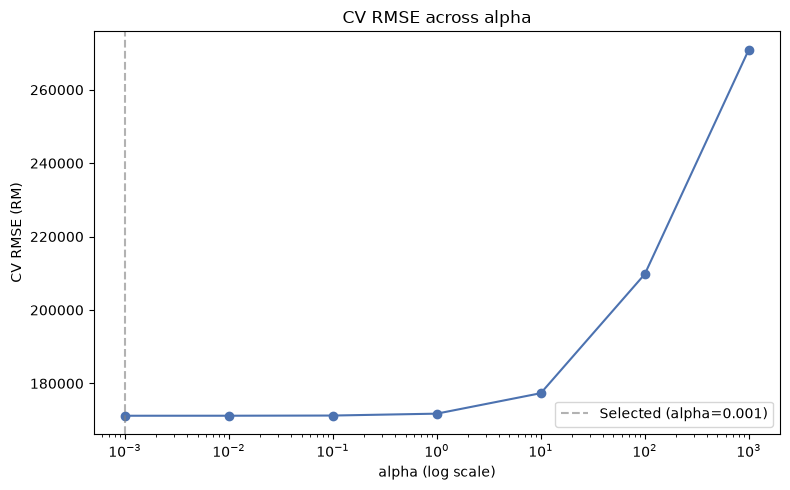

alpha=0.001: CV RMSE=RM171,191
alpha=0.01: CV RMSE=RM171,195
alpha=0.1: CV RMSE=RM171,245
alpha=1: CV RMSE=RM171,760
alpha=10: CV RMSE=RM177,338
alpha=100: CV RMSE=RM209,777
alpha=1000: CV RMSE=RM270,933


In [7]:
import matplotlib.pyplot as plt

best = bayes_search.best_params_
alpha_candidates = sorted({0.001, 0.01, 0.1, 1, 10, 100, 1000, best["alpha"]})
cv_rmse_by_alpha = []

for a in alpha_candidates:
    if a == best["alpha"]:
        cv_rmse_by_alpha.append(cv_results["mean"]["RMSE"])
        continue
    cv = cross_validate_model(Ridge(alpha=a), X_train, y_train, n_splits=5)
    cv_rmse_by_alpha.append(cv["mean"]["RMSE"])

plt.figure(figsize=(8, 5))
plt.plot(alpha_candidates, cv_rmse_by_alpha, marker="o", color="#4c72b0")
plt.axvline(x=best["alpha"], color="grey", linestyle="--", alpha=0.6, label=f"Selected (alpha={best['alpha']})")
plt.xscale("log")
plt.xlabel("alpha (log scale)")
plt.ylabel("CV RMSE (RM)")
plt.title("CV RMSE across alpha")
plt.legend()
plt.tight_layout()
plt.show()

for a, r in zip(alpha_candidates, cv_rmse_by_alpha):
    print(f"alpha={a}: CV RMSE=RM{r:,.0f}")